In [98]:
from lifelines import KaplanMeierFitter
from lifelines import AalenJohansenFitter
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from lifelines import CoxPHFitter

Testing lifelines and doing a standard KaplanMeier curve.

In [33]:
#Dataframe Notes: 0 = cancer (relapse?), 1 = lost to follow up, 2 = death, competiting
#DT_SECONDCANCER_DEATH, ENDPT_SECONDCANCER_DEATH,
df = pd.read_csv(r"C:\Users\Charm\Downloads\data_clinical_sample_ttnext_cancer_6-2-26.csv")

C:\Users\Charm\AppData\Local\Temp\ipykernel_42492\80286513.py:3: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\Charm\Downloads\data_clinical_sample_ttnext_cancer_6-2-26.csv")


In [34]:
sorted_df = df.sort_values(by = 'CURRENT_AGE_DEID')
dt = sorted_df['DT_SECONDCANCER_DEATH']
censored_val = sorted_df['ENDPT_SECONDCANCER_DEATH']
curr_age = sorted_df['CURRENT_AGE_DEID']
kmf = KaplanMeierFitter()
kmf.fit(dt, event_observed = censored_val)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 12306 total observations, 5435 right-censored observations>

<Axes: xlabel='timeline'>

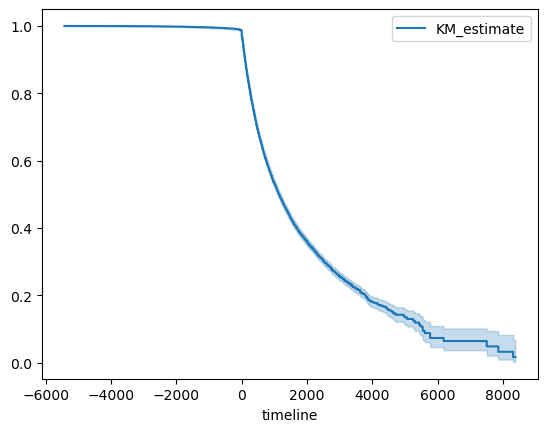

In [35]:
kmf.plot_survival_function()

Question: Does time of cancer relapse depend on age?
Approach: See how long people within certain age groups do not face an event (no death, cancer, etc)
Then, use Fine-Gray model to determine the Subdistibution Hazard Ratio to figure out whether those who are older are more likely to relapse in a shorter timeframe than those who are younger (SHR > 1) with death considered a competing factor.

In [36]:
curr_age.min()

np.int64(4)

In [37]:
curr_age.max()

np.int64(89)

In [38]:
len(curr_age.values)

12306

In [39]:
#sorted_df = df.sort_values(by = 'CURRENT_AGE_DEID')
#sorted_df

In [49]:
age_buckets = curr_age.values.reshape(6,2051)
age_buckets

array([[ 4,  8, 13, ..., 60, 60, 60],
       [60, 60, 60, ..., 67, 67, 67],
       [67, 67, 67, ..., 71, 71, 71],
       [71, 71, 71, ..., 76, 76, 76],
       [76, 76, 76, ..., 81, 81, 81],
       [81, 81, 81, ..., 89, 89, 89]], shape=(6, 2051))

In [52]:
age_buckets_labels = []
age_time = []
for row in age_buckets:
    #print(age_buckets[i])
    age_buckets_labels.append(f'{row.min()}-{row.max()}')
    #i = 0
    #for age in row:
     #   age_time[i] =
print(age_buckets_labels)
sorted_df['age_group'] = pd.cut(sorted_df['age'], bins = age_buckets_label)

['4-60', '60-67', '67-71', '71-76', '76-81', '81-89']


In [41]:
#age_buckets = np.zeros((6, 2051))
#j=0
#for i in range len(curr_age.values):
    #age_buckets[j] = curr_age.values[i:i+2051]
    #j+=1

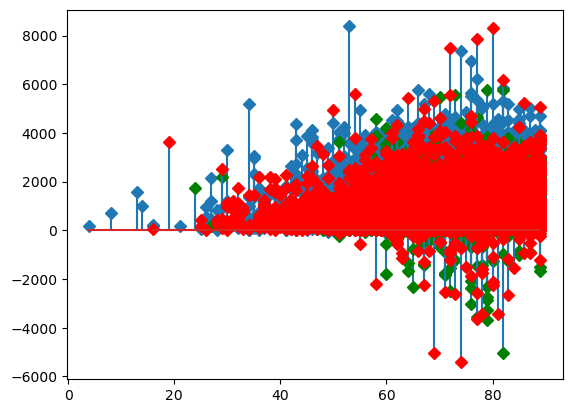

In [63]:
mask_0 = (censored_val == 0)
mask_1 = (censored_val == 1)
mask_2 = (censored_val == 2)
plt.stem(curr_age[mask_0], dt[mask_0], markerfmt = 'D')
plt.stem(curr_age[mask_1], dt[mask_1], markerfmt = 'gD')
plt.stem(curr_age[mask_2], dt[mask_2], markerfmt = 'rD')
plt.show()

So this is kind of crowded, lets do a box and whisker plot

C:\Users\Charm\AppData\Local\Temp\ipykernel_42492\3487590920.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped_data, labels=labels)


{'whiskers': [<matplotlib.lines.Line2D at 0x17160a09e80>,
 'caps': [<matplotlib.lines.Line2D at 0x17160a0a120>,
 'boxes': [<matplotlib.lines.Line2D at 0x17160a09d30>,
 'medians': [<matplotlib.lines.Line2D at 0x17160a0a3c0>,
 'fliers': [<matplotlib.lines.Line2D at 0x17160a0a510>,
 'means': []}

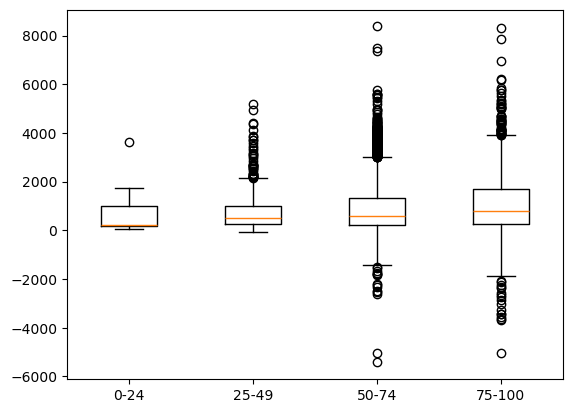

In [71]:
bins = [0, 25, 50, 75, 100]
labels = ['0-24', '25-49', '50-74', '75-100']
sorted_df['age_group'] = pd.cut(sorted_df['CURRENT_AGE_DEID'], bins = bins, labels= labels)
grouped_data = [sorted_df[sorted_df['age_group'] == label]['DT_SECONDCANCER_DEATH'] for label in labels]
plt.boxplot(grouped_data, labels=labels)

In [87]:
#If we only want 0 to represent the observed effect
sorted_df['Event_of_interest'] =(sorted_df['ENDPT_SECONDCANCER_DEATH'] != 0).astype(int)
sorted_df['Event_of_interest']

11896    0
2874     0
1280     0
9170     0
2305     0
        ..
4205     1
10505    1
4225     1
4226     1
8404     0
Name: Event_of_interest, Length: 12306, dtype: int64

<Axes: >

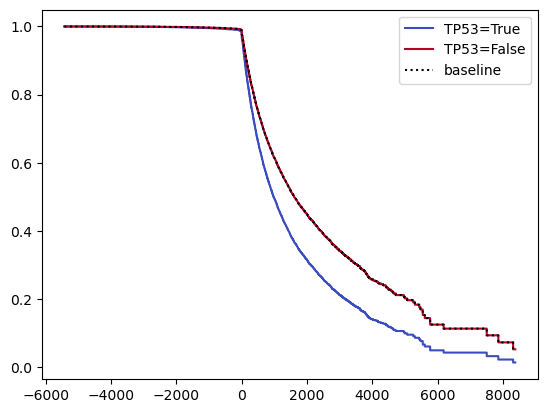

In [112]:
#Filter the df so that I don't get a value error because of the text columns...
cph_df = sorted_df[['DT_SECONDCANCER_DEATH', 'Event_of_interest', 'TP53', 'CURRENT_AGE_DEID', 'KRAS']]
cph = CoxPHFitter()
cph.fit(cph_df, duration_col = 'DT_SECONDCANCER_DEATH', event_col = 'Event_of_interest')
cph.plot_partial_effects_on_outcome(covariates='TP53', values=[True, False], cmap='coolwarm')

In [113]:
[i for i in sorted_df['CURRENT_AGE_DEID'].values]

[np.int64(4),
 np.int64(8),
 np.int64(13),
 np.int64(14),
 np.int64(16),
 np.int64(16),
 np.int64(16),
 np.int64(19),
 np.int64(21),
 np.int64(24),
 np.int64(25),
 np.int64(25),
 np.int64(25),
 np.int64(26),
 np.int64(26),
 np.int64(26),
 np.int64(26),
 np.int64(27),
 np.int64(27),
 np.int64(27),
 np.int64(27),
 np.int64(27),
 np.int64(27),
 np.int64(28),
 np.int64(28),
 np.int64(28),
 np.int64(28),
 np.int64(28),
 np.int64(28),
 np.int64(28),
 np.int64(28),
 np.int64(29),
 np.int64(29),
 np.int64(29),
 np.int64(29),
 np.int64(29),
 np.int64(30),
 np.int64(30),
 np.int64(30),
 np.int64(30),
 np.int64(30),
 np.int64(30),
 np.int64(30),
 np.int64(30),
 np.int64(30),
 np.int64(31),
 np.int64(31),
 np.int64(31),
 np.int64(31),
 np.int64(31),
 np.int64(31),
 np.int64(32),
 np.int64(32),
 np.int64(32),
 np.int64(32),
 np.int64(32),
 np.int64(32),
 np.int64(32),
 np.int64(32),
 np.int64(32),
 np.int64(32),
 np.int64(33),
 np.int64(33),
 np.int64(33),
 np.int64(33),
 np.int64(33),
 np.int64(33

In [114]:
#cph.fit(cph_df, duration_col = 'DT_SECONDCANCER_DEATH', event_col = 'Event_of_interest')
#cph.plot_partial_effects_on_outcome(covariates='CURRENT_AGE_DEID', values=[i for i in sorted_df['CURRENT_AGE_DEID'].values], cmap='coolwarm')


In [115]:
print(sorted_df['Event_of_interest'].dtypes, sorted_df['DT_SECONDCANCER_DEATH'].dtypes)

int64 int64


Let's make a cumulative incidence function, since lifelines doesn't have fine gray, we can use Aalen Johansen but it doesn't account for covariants (whereas the Cox Proportional Hazard Function accounts for covariants but not for competing factors...)

<Axes: xlabel='event_at'>

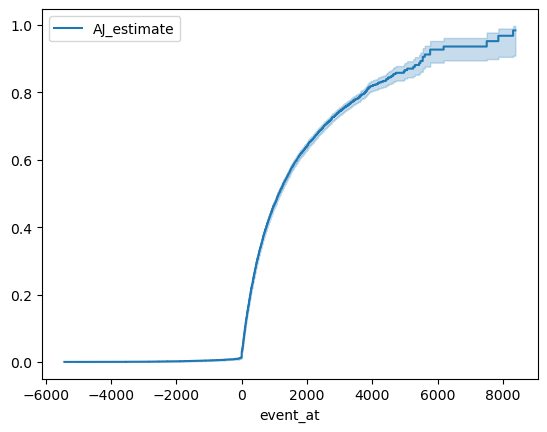

In [116]:
ajf = AalenJohansenFitter(calculate_variance = True)
ajf.fit(cph_df['DT_SECONDCANCER_DEATH'], cph_df['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()

Let's stratifying between people with TP53 mutation and those without.

In [117]:
mutated_TP53 = cph_df[cph_df['TP53'] == True]
nonmutated_TP53 = cph_df[cph_df['TP53'] == False]

<Axes: xlabel='event_at'>

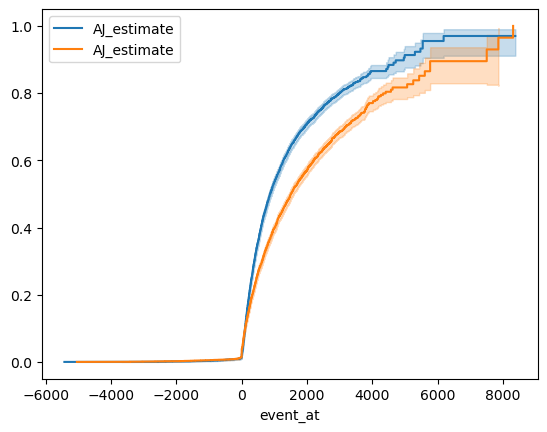

In [118]:
ajf.fit(mutated_TP53['DT_SECONDCANCER_DEATH'], mutated_TP53['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
ajf.fit(nonmutated_TP53['DT_SECONDCANCER_DEATH'], nonmutated_TP53['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
#Blue is mutated, Orange is unmutated

If the individual developed a secondary cancer, lets see how high the incidence is for someone with a TP53 and KRAS mutation

<Axes: xlabel='event_at'>

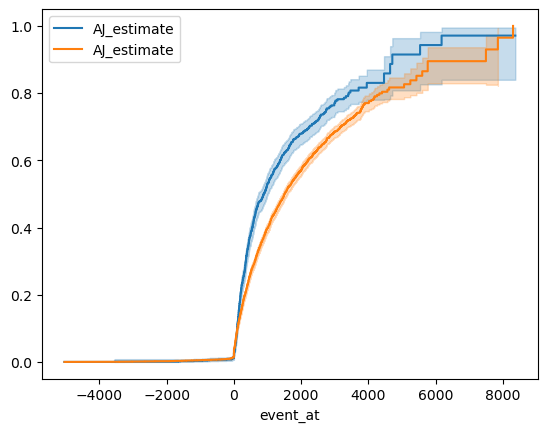

In [119]:
mutated_TP53_KRAS = mutated_TP53[mutated_TP53['KRAS'] == True]
ajf.fit(mutated_TP53_KRAS['DT_SECONDCANCER_DEATH'], mutated_TP53_KRAS['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
ajf.fit(nonmutated_TP53['DT_SECONDCANCER_DEATH'], nonmutated_TP53['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()

Lets look at how age impacts CIF


<Axes: xlabel='event_at'>

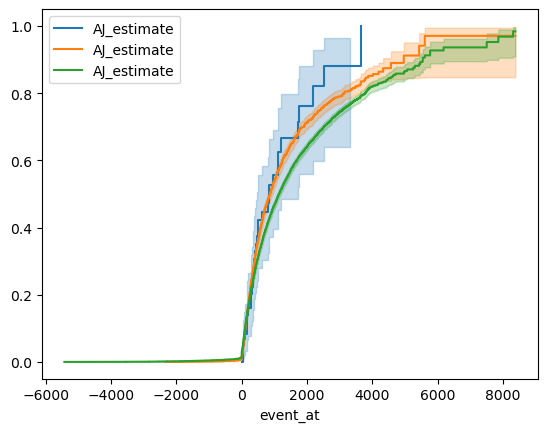

In [122]:
group_1 = cph_df[cph_df['CURRENT_AGE_DEID'] <= 32]
group_2 = cph_df[cph_df['CURRENT_AGE_DEID'] <= 65]
group_3 = cph_df[cph_df['CURRENT_AGE_DEID'] <= 99]
ajf.fit(group_1['DT_SECONDCANCER_DEATH'], group_1['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
ajf.fit(group_2['DT_SECONDCANCER_DEATH'], group_2['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
ajf.fit(group_3['DT_SECONDCANCER_DEATH'], group_3['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
#Blue, orange, green

Common NLSC are breast, prostate, and head and neck cancers. So I'll focus on mutations in either of the BRCA genes AND TP53.

In [ ]:
mutated_TP53_BRCA = mutated_TP53[mutated_TP53['BRCA1'] == True or mutated_TP53['BRCA2'] == True]
mutated_TP53_BRCA = mutated_TP53[mutated_TP53['BRCA1'] == True or mutated_TP53['BRCA2'] == True]